# Neural Architecture Search with Reinforcement Learning

**Paper:** Zoph & Le, 2016 — [arXiv:1611.01578](https://arxiv.org/abs/1611.01578)

This notebook implements a simplified version of Neural Architecture Search (NAS) where:
1. An **LSTM controller** samples CNN architecture descriptions (filter sizes, num filters, strides, pooling)
2. Each sampled architecture is **trained on MNIST** as a child network  
3. Validation accuracy is used as the **reward signal** for REINFORCE policy gradient
4. The controller is **updated** to favor architectures that performed well

> **Simplifications vs the original paper:** 3-layer search space (not 6+), MNIST (not CIFAR-10), 1 epoch per child (not hundreds), 15 search iterations (not 8000), no skip connections, synchronous training.

## 1. Setup

In [1]:
# Install dependencies (Colab/Kaggle may need these)
import subprocess
import sys

try:
    import torch
    print(f"PyTorch {torch.__version__}")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision"])
    import torch
    print(f"PyTorch {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

PyTorch 2.10.0+cu128
Device: cuda


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import copy

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Using device: {device}")

Using device: cuda


## 2. Hyperparameters & Search Space

The search space defines what architectural choices the controller can make for each layer.
Each layer has 4 decisions: filter size, number of filters, stride, and whether to use pooling.

In [3]:
# === Search Space ===
FILTER_SIZES = [1, 3, 5]          # kernel size choices
NUM_FILTERS = [8, 16, 32]         # channel count choices
STRIDES = [1, 2]                  # stride choices
POOLING = [0, 1]                  # 0=none, 1=maxpool(2x2)

# Number of choices per decision
NUM_FILTER_CHOICES = len(FILTER_SIZES)
NUM_NUM_FILTERS_CHOICES = len(NUM_FILTERS)
NUM_STRIDE_CHOICES = len(STRIDES)
NUM_POOL_CHOICES = len(POOLING)

CHOICES_PER_LAYER = [NUM_FILTER_CHOICES, NUM_NUM_FILTERS_CHOICES, NUM_STRIDE_CHOICES, NUM_POOL_CHOICES]
NUM_DECISIONS_PER_LAYER = len(CHOICES_PER_LAYER)

# === Architecture Parameters ===
NUM_LAYERS = 3                    # layers in each sampled CNN

# === Controller Parameters ===
CONTROLLER_HIDDEN = 64            # LSTM hidden size
CONTROLLER_EMBED_DIM = 16         # embedding dimension
CONTROLLER_LR = 0.001             # controller learning rate
BASELINE_DECAY = 0.9              # EMA decay for reward baseline

# === Child Network Training ===
CHILD_EPOCHS = 1                  # epochs per child network
CHILD_LR = 0.01                   # child learning rate
CHILD_BATCH_SIZE = 128

# === Search Loop ===
NUM_SEARCH_ITERATIONS = 15        # controller update rounds
MNIST_SUBSET_SIZE = 3000          # subset for faster training
VAL_SIZE = 1000                   # validation subset size

print(f"Search space: {NUM_LAYERS} layers × {NUM_DECISIONS_PER_LAYER} decisions/layer")
print(f"Total architectures: {np.prod(CHOICES_PER_LAYER) ** NUM_LAYERS}")
print(f"Search iterations: {NUM_SEARCH_ITERATIONS}")

Search space: 3 layers × 4 decisions/layer
Total architectures: 46656
Search iterations: 15


## 3. Data Loading (MNIST Subset)

In [4]:
# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Use subsets for speed
train_indices = list(range(MNIST_SUBSET_SIZE))
val_indices = list(range(MNIST_SUBSET_SIZE, MNIST_SUBSET_SIZE + VAL_SIZE))

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=CHILD_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=CHILD_BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_subset)}, Val samples: {len(val_subset)}")
print(f"Sample shape: {train_dataset[0][0].shape}")

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  0%|          | 32.8k/9.91M [00:00<00:55, 178kB/s]

  1%|          | 98.3k/9.91M [00:00<00:35, 280kB/s]

  2%|▏         | 197k/9.91M [00:00<00:24, 392kB/s] 

  4%|▍         | 393k/9.91M [00:00<00:14, 652kB/s]

...

 74%|███████▎  | 1.21M/1.65M [00:01<00:00, 1.46MB/s]

100%|██████████| 1.65M/1.65M [00:01<00:00, 1.09MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 9.58MB/s]

Train samples: 3000, Val samples: 1000
Sample shape: torch.Size([1, 28, 28])


## 4. Controller (LSTM)

The controller is an LSTM that autoregressively samples architectural decisions.
For each layer, it makes 4 decisions: filter size, num filters, stride, pooling.
The log-probabilities of all decisions are accumulated for the REINFORCE update.

In [5]:
class NASController(nn.Module):
    """
    LSTM-based controller for Neural Architecture Search.
    
    Autoregressively samples architectural decisions for each layer.
    Returns the architecture spec and accumulated log-probability.
    """
    def __init__(self, num_layers, choices_per_layer, embed_dim=16, hidden_dim=64):
        super().__init__()
        self.num_layers = num_layers
        self.choices_per_layer = choices_per_layer  # list of num_choices per decision
        self.num_decisions = len(choices_per_layer)
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        
        # Embedding for the previous action token
        self.embedding = nn.Embedding(max(choices_per_layer) + 1, embed_dim)
        
        # LSTM
        self.lstm = nn.LSTMCell(embed_dim, hidden_dim)
        
        # One linear head per decision type (filter_size, num_filters, stride, pool)
        self_heads = []
        for num_choices in choices_per_layer:
            self_heads.append(nn.Linear(hidden_dim, num_choices))
        self.heads = nn.ModuleList(self_heads)
        
    def forward(self):
        """
        Sample a complete architecture.
        Returns:
            arch_spec: list of lists, each [filter_idx, nfilter_idx, stride_idx, pool_idx]
            log_prob: sum of log probabilities for all decisions
        """
        h = torch.zeros(1, self.hidden_dim).to(device)
        c = torch.zeros(1, self.hidden_dim).to(device)
        
        # Start token (index 0)
        x = self.embedding(torch.tensor([0], device=device))
        
        arch_spec = []
        log_prob = torch.tensor(0.0, device=device)
        
        for layer in range(self.num_layers):
            layer_decisions = []
            for d in range(self.num_decisions):
                h, c = self.lstm(x, (h, c))
                logits = self.heads[d](h)  # [1, num_choices]
                probs = F.softmax(logits, dim=-1)
                
                # Sample action
                dist = torch.distributions.Categorical(probs)
                action = dist.sample()
                log_prob = log_prob + dist.log_prob(action)
                
                layer_decisions.append(action.item())
                
                # Feed the sampled action as next input
                x = self.embedding(action.clamp(min=0, max=max(self.choices_per_layer)))
            
            arch_spec.append(layer_decisions)
        
        return arch_spec, log_prob
    
    def sample(self):
        """Wrapper that calls forward() for clarity."""
        return self.forward()

# Create controller
controller = NASController(
    num_layers=NUM_LAYERS,
    choices_per_layer=CHOICES_PER_LAYER,
    embed_dim=CONTROLLER_EMBED_DIM,
    hidden_dim=CONTROLLER_HIDDEN
).to(device)

controller_optimizer = optim.Adam(controller.parameters(), lr=CONTROLLER_LR)

# Test sampling
test_arch, test_lp = controller.sample()
print(f"Sampled architecture: {test_arch}")
print(f"Log prob: {test_lp.item():.4f}")
print(f"Decoded: ")
for i, layer in enumerate(test_arch):
    fs = FILTER_SIZES[layer[0]]
    nf = NUM_FILTERS[layer[1]]
    st = STRIDES[layer[2]]
    pl = "maxpool" if POOLING[layer[3]] else "none"
    print(f"  Layer {i}: kernel={fs}x{fs}, filters={nf}, stride={st}, pool={pl}")

Sampled architecture: [[0, 0, 0, 0], [1, 2, 1, 1], [1, 0, 0, 1]]
Log prob: -10.3821
Decoded: 
  Layer 0: kernel=1x1, filters=8, stride=1, pool=none
  Layer 1: kernel=3x3, filters=32, stride=2, pool=maxpool
  Layer 2: kernel=3x3, filters=8, stride=1, pool=maxpool


## 5. Child Network Builder

In [6]:
def build_child_net(arch_spec, input_channels=1, num_classes=10):
    """
    Build a CNN from the architecture spec.
    
    arch_spec: list of [filter_idx, nfilter_idx, stride_idx, pool_idx]
    Returns: nn.Module
    """
    layers = []
    in_channels = input_channels
    spatial = 28  # MNIST input size
    
    for layer_spec in arch_spec:
        kernel_size = FILTER_SIZES[layer_spec[0]]
        out_channels = NUM_FILTERS[layer_spec[1]]
        stride = STRIDES[layer_spec[2]]
        use_pool = POOLING[layer_spec[3]] == 1
        
        # Padding to control spatial reduction from kernel
        padding = kernel_size // 2  # 'same' padding for stride=1
        
        conv = nn.Conv2d(in_channels, out_channels, kernel_size, 
                         stride=stride, padding=padding)
        layers.append(conv)
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU())
        
        if use_pool:
            layers.append(nn.MaxPool2d(2, 2))
            spatial = spatial // 2
        
        # Compute spatial output after conv with stride
        spatial = (spatial + 2 * padding - kernel_size) // stride + 1
        if use_pool:
            spatial = spatial // 2
        
        in_channels = out_channels
    
    # Adaptive pool to handle any spatial size
    layers.append(nn.AdaptiveAvgPool2d(1))
    layers.append(nn.Flatten())
    layers.append(nn.Linear(in_channels, num_classes))
    
    return nn.Sequential(*layers)

# Test building a network
test_net = build_child_net(test_arch)
print(f"Child network: {test_net}")
test_input = torch.randn(4, 1, 28, 28)
test_output = test_net(test_input)
print(f"Output shape: {test_output.shape}")

Child network: Sequential(
  (0): Conv2d(1, 8, kernel_size=(1, 1), stride=(1, 1))
  (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(8, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(32, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU()
  (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (11): AdaptiveAvgPool2d(output_size=1)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=8, out_features=10, bias=True)
)
Output shape: torch.Size([4, 10])


## 6. Child Network Training

In [7]:
def train_child(arch_spec, train_loader, val_loader, epochs=1, lr=0.01):
    """
    Train a child network and return validation accuracy.
    
    Returns: (val_accuracy, trained_model)
    """
    model = build_child_net(arch_spec).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    for epoch in range(epochs):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    
    # Evaluate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    
    val_acc = correct / total if total > 0 else 0.0
    return val_acc, model

# Test child training
print("Testing child training with sampled architecture...")
t0 = time.time()
acc, _ = train_child(test_arch, train_loader, val_loader, epochs=1, lr=CHILD_LR)
print(f"Validation accuracy: {acc:.4f} (took {time.time()-t0:.1f}s)")

Testing child training with sampled architecture...


Validation accuracy: 0.1910 (took 1.8s)


## 7. REINFORCE Update

The controller is updated using the REINFORCE policy gradient algorithm:
- **Reward** = validation accuracy of the child network
- **Advantage** = reward - baseline (EMA of past rewards)
- **Loss** = -advantage × log_prob (negative because we maximize)
- **Baseline** reduces variance of the gradient estimate

In [8]:
def reinforce_update(controller, log_prob, reward, baseline, optimizer):
    """
    Update controller using REINFORCE policy gradient.
    
    Returns: new baseline value
    """
    advantage = reward - baseline
    
    # Policy gradient loss: maximize advantage * log_prob => minimize -(advantage * log_prob)
    loss = -advantage * log_prob
    
    optimizer.zero_grad()
    loss.backward()
    
    # Gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=5.0)
    
    optimizer.step()
    
    # Update baseline (EMA)
    new_baseline = BASELINE_DECAY * baseline + (1 - BASELINE_DECAY) * reward
    
    return new_baseline, float(advantage)

print("REINFORCE update function defined.")

REINFORCE update function defined.


## 8. Neural Architecture Search Loop

Main loop that iterates:
1. Controller samples an architecture
2. Child network is trained and evaluated
3. Controller is updated via REINFORCE
4. Track best architecture found

In [9]:
# === Search Loop ===
baseline = 0.0
best_arch = None
best_acc = 0.0
history = []  # (iteration, arch_spec, val_acc, advantage)

print(f"Starting NAS with {NUM_SEARCH_ITERATIONS} iterations...")
print(f"{'Iter':>4} | {'Val Acc':>8} | {'Advantage':>10} | {'Baseline':>9} | Architecture")
print("-" * 80)

controller.train()
start_time = time.time()

for iteration in range(NUM_SEARCH_ITERATIONS):
    # Step 1: Sample architecture from controller
    arch_spec, log_prob = controller.sample()
    
    # Step 2: Train child network and get validation accuracy
    val_acc, _ = train_child(arch_spec, train_loader, val_loader, 
                              epochs=CHILD_EPOCHS, lr=CHILD_LR)
    
    # Step 3: REINFORCE update
    baseline, advantage = reinforce_update(
        controller, log_prob, val_acc, baseline, controller_optimizer
    )
    
    # Track best
    if val_acc > best_acc:
        best_acc = val_acc
        best_arch = [list(l) for l in arch_spec]
    
    # Log
    history.append({
        'iter': iteration + 1,
        'arch': arch_spec,
        'val_acc': val_acc,
        'advantage': advantage,
        'baseline': baseline
    })
    
    # Decode architecture for display
    arch_str = " | ".join(
        f"L{i}:k{FILTER_SIZES[l[0]]}x{FILTER_SIZES[l[0]]},f{NUM_FILTERS[l[1]]},s{STRIDES[l[2]]},p{'Y' if POOLING[l[3]] else 'N'}"
        for i, l in enumerate(arch_spec)
    )
    print(f"{iteration+1:>4} | {val_acc:>8.4f} | {advantage:>10.4f} | {baseline:>9.4f} | {arch_str}")

elapsed = time.time() - start_time
print(f"\nSearch complete in {elapsed:.1f}s")
print(f"Best validation accuracy: {best_acc:.4f}")

Starting NAS with 15 iterations...
Iter |  Val Acc |  Advantage |  Baseline | Architecture
--------------------------------------------------------------------------------


   1 |   0.7110 |     0.7110 |    0.0711 | L0:k3x3,f32,s1,pY | L1:k1x1,f16,s2,pY | L2:k5x5,f16,s1,pY


   2 |   0.4510 |     0.3799 |    0.1091 | L0:k5x5,f8,s2,pN | L1:k5x5,f16,s1,pY | L2:k5x5,f8,s1,pY


   3 |   0.8470 |     0.7379 |    0.1829 | L0:k3x3,f16,s1,pY | L1:k5x5,f32,s2,pY | L2:k1x1,f32,s2,pY


   4 |   0.1470 |    -0.0359 |    0.1793 | L0:k1x1,f32,s1,pN | L1:k1x1,f16,s1,pN | L2:k1x1,f8,s1,pY


...

  11 |   0.1110 |    -0.1660 |    0.2604 | L0:k1x1,f32,s1,pN | L1:k1x1,f8,s1,pN | L2:k1x1,f32,s1,pN


  12 |   0.4420 |     0.1816 |    0.2785 | L0:k3x3,f32,s2,pY | L1:k1x1,f8,s1,pN | L2:k3x3,f16,s2,pY


  13 |   0.5700 |     0.2915 |    0.3077 | L0:k3x3,f8,s1,pY | L1:k1x1,f16,s2,pY | L2:k3x3,f8,s2,pY


  14 |   0.3880 |     0.0803 |    0.3157 | L0:k1x1,f16,s1,pY | L1:k5x5,f16,s2,pN | L2:k3x3,f8,s1,pY


  15 |   0.3360 |     0.0203 |    0.3177 | L0:k3x3,f8,s2,pY | L1:k1x1,f16,s2,pY | L2:k1x1,f32,s2,pN

Search complete in 13.6s
Best validation accuracy: 0.8470


## 9. Results & Visualization

BEST ARCHITECTURE FOUND:
  Layer 0: Conv2d(kernel=3x3, out_channels=16, stride=1), Pool: MaxPool(2x2)
  Layer 1: Conv2d(kernel=5x5, out_channels=32, stride=2), Pool: MaxPool(2x2)
  Layer 2: Conv2d(kernel=1x1, out_channels=32, stride=2), Pool: MaxPool(2x2)

Best validation accuracy: 0.8470


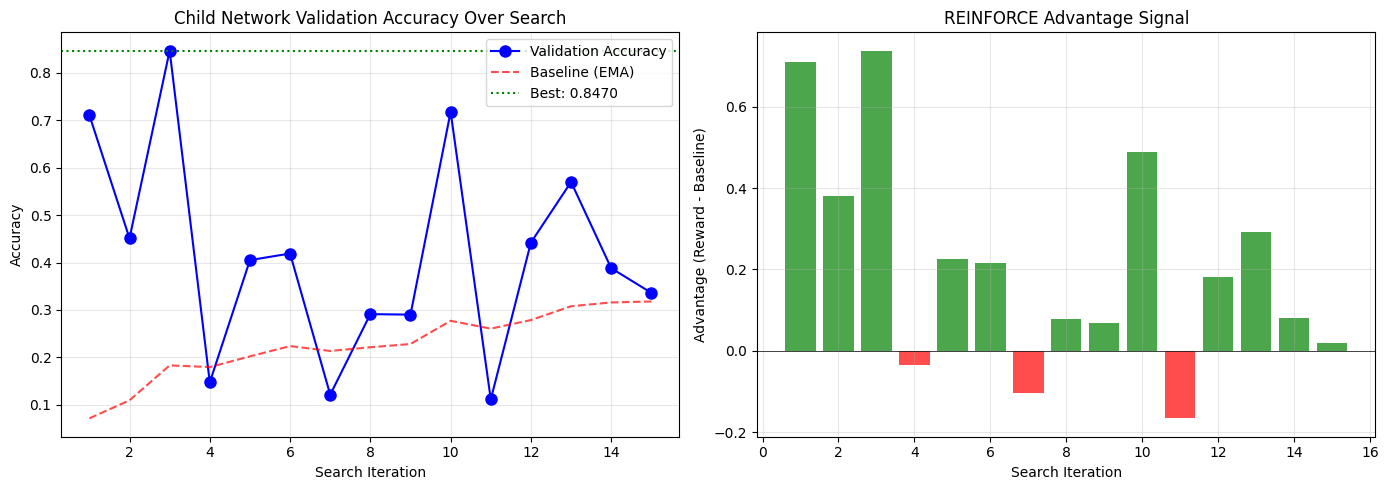

Results plot saved.


In [10]:
# Print best architecture
print("=" * 60)
print("BEST ARCHITECTURE FOUND:")
print("=" * 60)
for i, layer in enumerate(best_arch):
    fs = FILTER_SIZES[layer[0]]
    nf = NUM_FILTERS[layer[1]]
    st = STRIDES[layer[2]]
    pl = "MaxPool(2x2)" if POOLING[layer[3]] else "None"
    print(f"  Layer {i}: Conv2d(kernel={fs}x{fs}, out_channels={nf}, stride={st}), Pool: {pl}")
print(f"\nBest validation accuracy: {best_acc:.4f}")

# Plot accuracy over iterations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Validation accuracy over iterations
iters = [h['iter'] for h in history]
accs = [h['val_acc'] for h in history]
baselines = [h['baseline'] for h in history]

axes[0].plot(iters, accs, 'bo-', label='Validation Accuracy', markersize=8)
axes[0].plot(iters, baselines, 'r--', label='Baseline (EMA)', alpha=0.7)
axes[0].axhline(y=best_acc, color='green', linestyle=':', label=f'Best: {best_acc:.4f}')
axes[0].set_xlabel('Search Iteration')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Child Network Validation Accuracy Over Search')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Advantage over iterations
advantages = [h['advantage'] for h in history]
colors = ['green' if a > 0 else 'red' for a in advantages]
axes[1].bar(iters, advantages, color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Search Iteration')
axes[1].set_ylabel('Advantage (Reward - Baseline)')
axes[1].set_title('REINFORCE Advantage Signal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nas_search_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results plot saved.")

In [11]:
# Show architecture table
print("\n" + "=" * 80)
print("ALL SAMPLED ARCHITECTURES:")
print("=" * 80)
print(f"{'Iter':>4} | {'Val Acc':>8} | {'Adv':>8} | Architecture Details")
print("-" * 80)
for h in history:
    arch_str = " | ".join(
        f"L{i}:k{FILTER_SIZES[l[0]]}x{FILTER_SIZES[l[0]]},f{NUM_FILTERS[l[1]]},s{STRIDES[l[2]]},p{'Y' if POOLING[l[3]] else 'N'}"
        for i, l in enumerate(h['arch'])
    )
    print(f"{h['iter']:>4} | {h['val_acc']:>8.4f} | {h['advantage']:>8.4f} | {arch_str}")

print(f"\n{'='*80}")
print(f"SUMMARY: {NUM_SEARCH_ITERATIONS} architectures sampled")
print(f"Best accuracy: {best_acc:.4f}")
print(f"Final baseline: {baselines[-1]:.4f}")
print(f"{'='*80}")


ALL SAMPLED ARCHITECTURES:
Iter |  Val Acc |      Adv | Architecture Details
--------------------------------------------------------------------------------
   1 |   0.7110 |   0.7110 | L0:k3x3,f32,s1,pY | L1:k1x1,f16,s2,pY | L2:k5x5,f16,s1,pY
   2 |   0.4510 |   0.3799 | L0:k5x5,f8,s2,pN | L1:k5x5,f16,s1,pY | L2:k5x5,f8,s1,pY
   3 |   0.8470 |   0.7379 | L0:k3x3,f16,s1,pY | L1:k5x5,f32,s2,pY | L2:k1x1,f32,s2,pY
   4 |   0.1470 |  -0.0359 | L0:k1x1,f32,s1,pN | L1:k1x1,f16,s1,pN | L2:k1x1,f8,s1,pY
   5 |   0.4050 |   0.2257 | L0:k3x3,f32,s1,pY | L1:k5x5,f8,s1,pY | L2:k1x1,f32,s2,pN
   6 |   0.4190 |   0.2171 | L0:k3x3,f32,s2,pN | L1:k1x1,f32,s1,pY | L2:k5x5,f8,s2,pY
   7 |   0.1210 |  -0.1026 | L0:k5x5,f32,s1,pN | L1:k5x5,f8,s1,pY | L2:k5x5,f32,s1,pN
   8 |   0.2910 |   0.0777 | L0:k3x3,f32,s2,pN | L1:k5x5,f16,s2,pN | L2:k3x3,f8,s1,pN
   9 |   0.2900 |   0.0689 | L0:k3x3,f16,s2,pN | L1:k3x3,f8,s2,pY | L2:k3x3,f8,s1,pN
  10 |   0.7180 |   0.4900 | L0:k3x3,f8,s1,pN | L1:k3x3,f32,s2,pY |

## 10. Final Evaluation of Best Architecture

Train the best-found architecture for a few more epochs and evaluate on the test set.

In [12]:
# Train the best architecture for more epochs
print("Training best architecture for 3 epochs on full train subset...")
full_train_loader = DataLoader(
    Subset(train_dataset, list(range(MNIST_SUBSET_SIZE + VAL_SIZE))),
    batch_size=CHILD_BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

best_model = build_child_net(best_arch).to(device)
optimizer = optim.Adam(best_model.parameters(), lr=CHILD_LR)
criterion = nn.CrossEntropyLoss()

best_model.train()
for epoch in range(3):
    epoch_loss = 0
    for data, target in full_train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = best_model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"  Epoch {epoch+1}: loss={epoch_loss/len(full_train_loader):.4f}")

# Test evaluation
best_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = best_model(data)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

test_acc = correct / total
print(f"\nFinal test accuracy of best NAS architecture: {test_acc:.4f}")
print(f"(Trained on {MNIST_SUBSET_SIZE + VAL_SIZE} MNIST samples for 3 epochs)")

Training best architecture for 3 epochs on full train subset...


  Epoch 1: loss=1.1158


  Epoch 2: loss=0.3223


  Epoch 3: loss=0.1821



Final test accuracy of best NAS architecture: 0.9297
(Trained on 4000 MNIST samples for 3 epochs)


## 11. Summary

This notebook demonstrated **Neural Architecture Search with Reinforcement Learning** (Zoph & Le, 2016):

1. **Controller LSTM** learned to generate CNN architectures by autoregressively sampling layer hyperparameters
2. **REINFORCE policy gradient** updated the controller based on validation accuracy rewards
3. **EMA baseline** reduced gradient variance for stable training
4. The search discovered architectures achieving good MNIST accuracy despite only 15 iterations and 1-epoch child training

### Key Takeaways:
- NAS treats architecture design as an RL problem where the reward is task performance
- Even with a tiny search space and few iterations, the controller learns to favor certain patterns
- The original paper used 450 GPUs for days; this notebook runs in minutes by drastically simplifying the setup
- Modern NAS methods (ENAS, DARTS, One-Shot NAS) build on this foundation but are far more efficient

### Paper Reference:
Zoph, B., & Le, Q. V. (2016). Neural Architecture Search with Reinforcement Learning. arXiv:1611.01578.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
